# 02 — Cramer's Theorem: Bernoulli Tail Risk and Exact Binomial Tails

> **Project:** `large-deviations`  
> **Theme:** Cramer's theorem, exact binomial tail probabilities, logarithmic asymptotics, and credit tail risk  
> **Distribution:** Bernoulli / Binomial

This notebook is the numerical companion to the Cramer theory note.

The goal is to verify, on an exactly computable Bernoulli example, the logarithmic approximation

$$
\mathbb P\left(\frac{S_n}{n}\geq q\right)
\approx
\exp(-n\Gamma^*(q)),
$$

or equivalently

$$
-\frac{1}{n}
\log
\mathbb P\left(\frac{S_n}{n}\geq q\right)
\longrightarrow
\Gamma^*(q).
$$

Here

$$
S_n=X_1+\cdots+X_n,
\qquad
X_i\sim\mathrm{Bernoulli}(p).
$$

In credit-risk language, each $X_i$ can be interpreted as a default indicator. Then
$S_n/n$ is the realized default rate, and the event $S_n/n\geq q$ is a large-loss event.


## Position in the project

This notebook comes after the theory notes:

- `docs/foundations/exponential_tilting.md`
- `docs/foundations/cramers_theorem_from_scratch.md`
- `docs/distributions/bernoulli.md`

The role of this notebook is to turn the abstract Cramer statement

$$
\lim_{n\to\infty}
\frac{1}{n}
\log
\mathbb P\left(\frac{S_n}{n}\geq q\right)
=
-\Gamma^*(q)
$$

into a concrete numerical experiment.

The workflow is:

```text
Cramer theorem
-> Bernoulli rate function
-> exact binomial tail probability
-> empirical logarithmic rate
-> credit-risk interpretation
```

This notebook deliberately uses exact binomial probabilities rather than Monte Carlo.

Why?

Because before using simulation methods, we want a clean benchmark showing what the true rare-event probability is and how its logarithmic rate behaves.

The next step will be to estimate the same probability by simulation and compare:

```text
naive Monte Carlo
vs
exponential-tilting importance sampling
```

## 1. Imports and project setup

The notebook is designed to run from either:

- the repository root,
- the `notebooks/` directory,
- or an environment where the package has been installed.

When run inside the repository, it imports the package implementation from `src/large_deviations`.


In [12]:
from pathlib import Path
import sys
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binom
from IPython.display import display

# Make the project package importable from the repository root or from notebooks/.
cwd = Path.cwd().resolve()
candidate_roots = [cwd, cwd.parent]

for root in candidate_roots:
    src_path = root / "src"
    if src_path.exists() and str(src_path) not in sys.path:
        sys.path.insert(0, str(src_path))

from large_deviations import bernoulli_ld
from large_deviations.tilting import theta_for_tilted_mean, tilting_summary


def binomial_tail_threshold(n: int, level: float) -> int:
    """Return the integer threshold k for the event S_n / n >= level."""
    return int(math.ceil(n * level - 1e-12))


def exact_binomial_tail_log_probability(n: int, p: float, level: float) -> tuple[int, float]:
    """Return k and log P[Binomial(n,p) >= k], where k = ceil(n * level)."""
    k = binomial_tail_threshold(n, level)
    log_tail = float(binom.logsf(k - 1, n, p))
    return k, log_tail


def safe_exp(log_value: float) -> float:
    """Exponentiate a log-probability while avoiding underflow warnings."""
    if log_value < -745:
        return 0.0
    return float(np.exp(log_value))


plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})


## 2. Tail-risk parameters

We use a Bernoulli default indicator:

$$
X_i =
\begin{cases}
1, & \text{default},\\
0, & \text{no default}.
\end{cases}
$$

The true marginal default probability is:

$$
p=0.02.
$$

We study a stressed default-rate threshold:

$$
q=0.10.
$$

So the rare event is:

$$
\frac{S_n}{n}\geq q.
$$

This means: the realized default rate is at least \(10\%\), even though the true default probability is \(2\%\).


In [13]:
p = 0.02
q = 0.10

dist = bernoulli_ld(p)

theta_q = theta_for_tilted_mean(dist, target_mean=q)
tilt = tilting_summary(dist, theta_q)
rate_q = dist.rate_function(q)

parameter_summary = pd.DataFrame(
    {
        "quantity": [
            "true default probability p",
            "tail threshold q",
            "saddle-point theta_q",
            "tilted Bernoulli parameter p_theta",
            "Gamma(theta_q)",
            "Gamma*(q)",
        ],
        "value": [
            p,
            q,
            theta_q,
            float(tilt.tilted_parameter),
            tilt.cgf,
            rate_q,
        ],
    }
)

display(parameter_summary)


,quantity,value
0,true default probability p,0.020000
1,tail threshold q,0.100000
2,saddle-point theta_q,1.694596
3,tilted Bernoulli parameter p_theta,0.100000
4,Gamma(theta_q),0.085158
5,Gamma*(q),0.084302


## 3. The Cramer prediction

For Bernoulli variables, the rate function is:

$$
\Gamma^*(q)
=
q\log\frac{q}{p}
+
(1-q)\log\frac{1-q}{1-p}.
$$

Cramer's theorem predicts the leading logarithmic behavior:

$$
\mathbb P\left(\frac{S_n}{n}\geq q\right)
\approx
\exp(-n\Gamma^*(q)).
$$

The right numerical object to compare with $\Gamma^*(q)$ is therefore not the raw probability, but

$$
-\frac{1}{n}
\log
\mathbb P\left(\frac{S_n}{n}\geq q\right).
$$

This quantity should converge to $\Gamma^*(q)$ as $n$ increases.


In [3]:
n_values = np.array([50, 100, 200, 500, 1_000, 2_000, 5_000], dtype=int)

rows = []

for n in n_values:
    k, log_tail = exact_binomial_tail_log_probability(n, p, q)
    empirical_rate = -log_tail / n
    cramer_log_approx = -n * rate_q
    cramer_probability_approx = safe_exp(cramer_log_approx)
    tail_probability = safe_exp(log_tail)

    rows.append(
        {
            "n": n,
            "expected_defaults_np": n * p,
            "tail_threshold_k": k,
            "tail_level_k_over_n": k / n,
            "log_exact_tail_probability": log_tail,
            "exact_tail_probability": tail_probability,
            "cramer_log_approximation": cramer_log_approx,
            "cramer_probability_approximation": cramer_probability_approx,
            "empirical_rate_-logP_over_n": empirical_rate,
            "Gamma_star_q": rate_q,
            "rate_error": empirical_rate - rate_q,
            "relative_rate_error": (empirical_rate - rate_q) / rate_q,
        }
    )

tail_table = pd.DataFrame(rows)

display(tail_table)


,n,expected_defaults_np,tail_threshold_k,tail_level_k_over_n,log_exact_tail_probability,exact_tail_probability,cramer_log_approximation,cramer_probability_approximation,empirical_rate_-logP_over_n,Gamma_star_q,rate_error,relative_rate_error
0,50,1.0,5,0.1,-5.741565,3.209742e-03,-4.215088,1.477102e-02,0.114831,0.084302,0.030530,0.362146
1,100,2.0,10,0.1,-10.276966,3.441681e-05,-8.430176,2.181830e-04,0.102770,0.084302,0.018468,0.219069
2,200,4.0,20,0.1,-19.038593,5.390686e-09,-16.860353,4.760382e-08,0.095193,0.084302,0.010891,0.129193
3,500,10.0,50,0.1,-44.777311,3.576523e-20,-42.150882,4.944298e-19,0.089555,0.084302,0.005253,0.062310
4,1000,20.0,100,0.1,-87.271267,1.254787e-38,-84.301764,2.444608e-37,0.087271,0.084302,0.002970,0.035225
5,2000,40.0,200,0.1,-171.917817,2.172904e-75,-168.603527,5.976107e-74,0.085959,0.084302,0.001657,0.019657
6,5000,100.0,500,0.1,-425.280169,2.009876e-185,-421.508819,8.730638e-184,0.085056,0.084302,0.000754,0.008947


## 4. Numerical verification of Cramer's theorem

The table above computes the exact probability using the binomial survival function:

$$
\mathbb P(S_n\ge k),
\qquad
k=\lceil nq\rceil.
$$

Now we plot

$$
-\frac{1}{n}\log\mathbb P(S_n/n\geq q)
$$

against $n$, and compare it with the horizontal line $\Gamma^*(q)$.


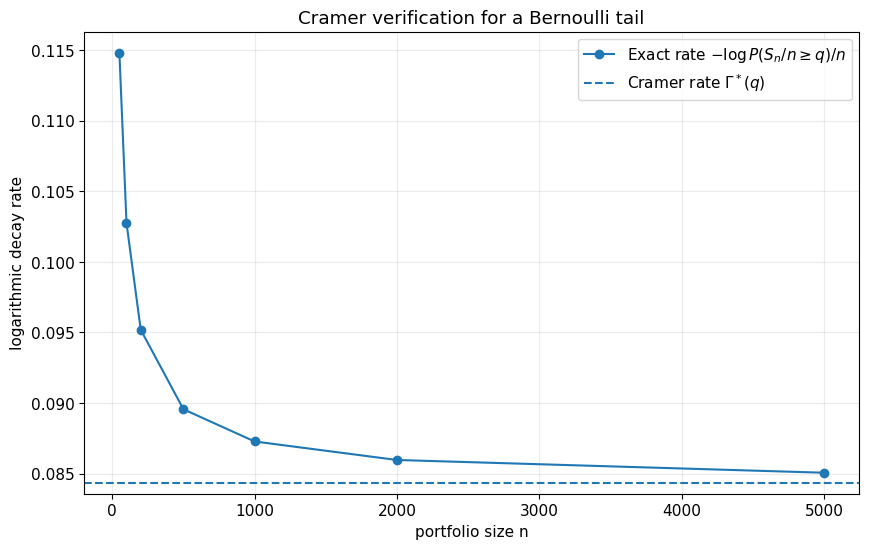

In [4]:
plt.figure()
plt.plot(
    tail_table["n"],
    tail_table["empirical_rate_-logP_over_n"],
    marker="o",
    label=r"Exact rate $-\log P(S_n/n\geq q)/n$"
,
)
plt.axhline(
    rate_q,
    linestyle="--",
    label=r"Cramer rate $\Gamma^*(q)$",
)
plt.xlabel("portfolio size n")
plt.ylabel("logarithmic decay rate")
plt.title("Cramer verification for a Bernoulli tail")
plt.legend()
plt.show()


The convergence is not about exact finite $n$ equality. It is about the leading exponential order.

That is why the rate error

$$
-\frac{1}{n}\log P(S_n/n\geq q)-\Gamma^*(q)
$$

should get smaller as $n$ grows.


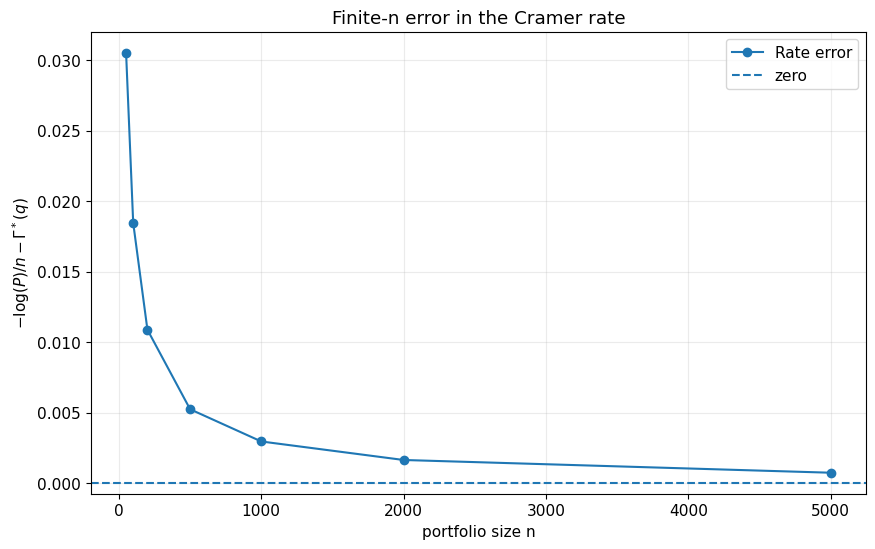

In [5]:
plt.figure()
plt.plot(
    tail_table["n"],
    tail_table["rate_error"],
    marker="o",
    label=r"Rate error",
)
plt.axhline(0.0, linestyle="--", label="zero")
plt.xlabel("portfolio size n")
plt.ylabel(r"$-\log(P)/n-\Gamma^*(q)$")
plt.title("Finite-n error in the Cramer rate")
plt.legend()
plt.show()


## 5. Exact log-tail versus Cramer leading order

Cramer's theorem says that the slope of the log probability is governed by $-\Gamma^*(q)$:

$$
\log \mathbb P(S_n/n\geq q)
\approx
-n\Gamma^*(q).
$$

The next plot compares:

1. the exact log tail probability;
2. the Cramer leading-order log approximation.


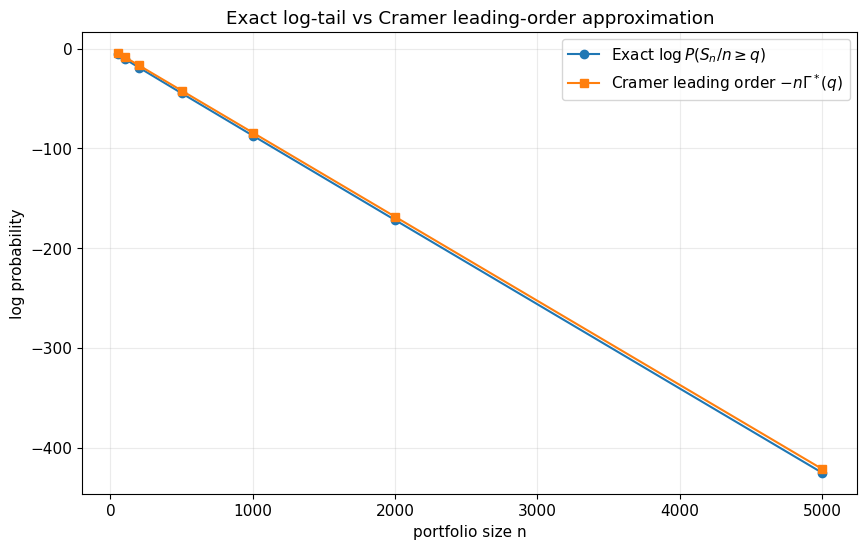

In [6]:
plt.figure()
plt.plot(
    tail_table["n"],
    tail_table["log_exact_tail_probability"],
    marker="o",
    label=r"Exact $\log P(S_n/n\geq q)$",
)
plt.plot(
    tail_table["n"],
    tail_table["cramer_log_approximation"],
    marker="s",
    label=r"Cramer leading order $-n\Gamma^*(q)$",
)
plt.xlabel("portfolio size n")
plt.ylabel("log probability")
plt.title("Exact log-tail vs Cramer leading-order approximation")
plt.legend()
plt.show()


## 6. Probability scale

The approximation

$$
P(S_n/n\geq q)\approx e^{-n\Gamma^*(q)}
$$

is a leading exponential approximation.

It can be rough on the raw probability scale for moderate \(n\), because Cramer keeps only the exponential rate and ignores subexponential correction factors.


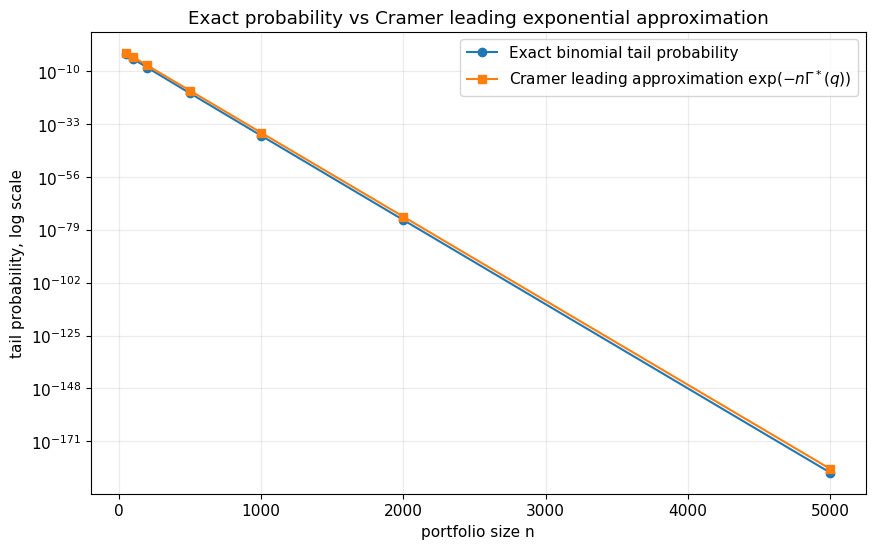

In [7]:
plt.figure()
plt.semilogy(
    tail_table["n"],
    tail_table["exact_tail_probability"],
    marker="o",
    label="Exact binomial tail probability",
)
plt.semilogy(
    tail_table["n"],
    tail_table["cramer_probability_approximation"],
    marker="s",
    label=r"Cramer leading approximation $\exp(-n\Gamma^*(q))$",
)
plt.xlabel("portfolio size n")
plt.ylabel("tail probability, log scale")
plt.title("Exact probability vs Cramer leading exponential approximation")
plt.legend()
plt.show()


## 7. Subexponential correction

Pham emphasizes that large deviations mainly captures the leading logarithmic term.

To see what is being ignored, define the correction factor

$$
C_n
=
\exp(n\Gamma^*(q))
\mathbb P(S_n/n\geq q).
$$

Taking logs:

$$
\log C_n
=
\log \mathbb P(S_n/n\geq q)+n\Gamma^*(q).
$$

Cramer says:

$$
\frac{1}{n}\log C_n\to 0.
$$

So $C_n$ may vary with $n$, but it should not contribute at exponential scale.


,n,log_subexponential_correction,subexponential_correction
0,50,-1.526477,0.217300
1,100,-1.846789,0.157743
2,200,-2.178240,0.113241
3,500,-2.626429,0.072336
4,1000,-2.969504,0.051329
5,2000,-3.314290,0.036360
6,5000,-3.771350,0.023021


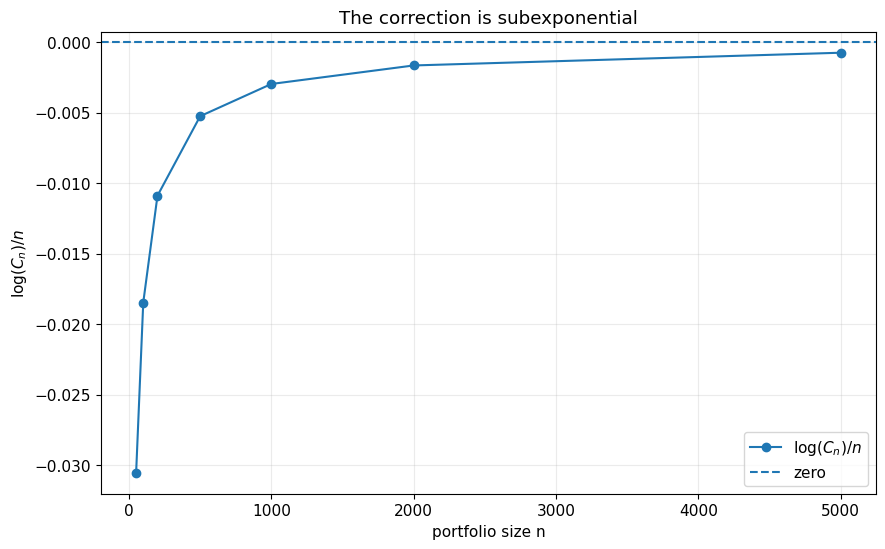

In [8]:
tail_table["log_subexponential_correction"] = (
    tail_table["log_exact_tail_probability"] + tail_table["n"] * rate_q
)

tail_table["subexponential_correction"] = tail_table[
    "log_subexponential_correction"
].map(safe_exp)

display(
    tail_table[
        [
            "n",
            "log_subexponential_correction",
            "subexponential_correction",
        ]
    ]
)

plt.figure()
plt.plot(
    tail_table["n"],
    tail_table["log_subexponential_correction"] / tail_table["n"],
    marker="o",
    label=r"$\log(C_n)/n$",
)
plt.axhline(0.0, linestyle="--", label="zero")
plt.xlabel("portfolio size n")
plt.ylabel(r"$\log(C_n)/n$")
plt.title("The correction is subexponential")
plt.legend()
plt.show()


## 8. Credit-risk interpretation

For a homogeneous independent credit portfolio:

- $n$ is the number of obligors;
- $X_i$ is the default indicator of obligor $i$;
- $p$ is the marginal default probability;
- $S_n$ is the number of defaults;
- $S_n/n$ is the realized default rate.

The tail event

$$
S_n/n\geq q
$$

is a large-loss event.

Cramer's theorem says that, when defaults are independent Bernoulli variables,

$$
\mathbb P(S_n/n\geq q)
$$

decays exponentially with portfolio size $n$, and the decay rate is the Bernoulli rate function $\Gamma^*(q)$.


In [9]:
selected_n = 1_000
selected_k, selected_log_tail = exact_binomial_tail_log_probability(selected_n, p, q)

credit_summary = pd.DataFrame(
    {
        "quantity": [
            "number of obligors n",
            "default probability p",
            "expected number of defaults np",
            "large-loss threshold q",
            "default-count threshold ceil(nq)",
            "exact log tail probability",
            "exact tail probability",
            "Cramer log approximation",
            "Cramer probability approximation",
        ],
        "value": [
            selected_n,
            p,
            selected_n * p,
            q,
            selected_k,
            selected_log_tail,
            safe_exp(selected_log_tail),
            -selected_n * rate_q,
            safe_exp(-selected_n * rate_q),
        ],
    }
)

display(credit_summary)


,quantity,value
0,number of obligors n,1.000000e+03
1,default probability p,2.000000e-02
2,expected number of defaults np,2.000000e+01
3,large-loss threshold q,1.000000e-01
4,default-count threshold ceil(nq),1.000000e+02
5,exact log tail probability,-8.727127e+01
6,exact tail probability,1.254787e-38
7,Cramer log approximation,-8.430176e+01
8,Cramer probability approximation,2.444608e-37


## 9. Saddle point: why this prepares importance sampling

The notebook has so far verified the Cramer rate using exact binomial probabilities.

The saddle-point now explains how this connects to the next simulation step.

The saddle-point equation is

$$
\Gamma'(\theta_q)=q.
$$

For Bernoulli variables, \(\Gamma'(\theta)\) is the tilted success probability:

$$
p_\theta
=
\frac{p e^\theta}{1-p+p e^\theta}.
$$

Thus, choosing \(\theta_q\) makes the tilted default probability equal to the stress level:

$$
p_{\theta_q}=q.
$$

Interpretation:

```text
Original law:
typical default rate = p

Tilted law:
typical default rate = q
```

So the event

$$
S_n/n\geq q
$$

is rare under the original law, but becomes typical under the tilted law.

This notebook does not implement importance sampling yet. It identifies the exact rare-event probability and the saddle-point that will later be used for importance sampling.

In [10]:
theta_summary = pd.DataFrame(
    {
        "quantity": [
            "theta_q solving Gamma'(theta)=q",
            "exp(theta_q), one-unit odds multiplier",
            "original default probability p",
            "tilted default probability p_theta_q",
            "target default rate q",
        ],
        "value": [
            theta_q,
            np.exp(theta_q),
            p,
            float(tilt.tilted_parameter),
            q,
        ],
    }
)

display(theta_summary)


,quantity,value
0,theta_q solving Gamma'(theta)=q,1.694596
1,"exp(theta_q), one-unit odds multiplier",5.444444
2,original default probability p,0.020000
3,tilted default probability p_theta_q,0.100000
4,target default rate q,0.100000


## 10. Main takeaway

This notebook verifies the core numerical prediction of Cramer's theorem:

$$
-\frac{1}{n}
\log
\mathbb P\left(\frac{S_n}{n}\geq q\right)
\to
\Gamma^*(q).
$$

For Bernoulli variables,

$$
\Gamma^*(q)
=
q\log\frac{q}{p}
+
(1-q)\log\frac{1-q}{1-p}.
$$

The key point is not that

$$
\mathbb P(S_n/n\geq q)
$$

is exactly equal to

$$
e^{-n\Gamma^*(q)}.
$$

The key point is that both have the same leading exponential decay rate.

In the credit-risk interpretation, this means:

>As the portfolio size $n$ grows,
>the probability of observing a default rate above $q$
>decays exponentially,
>with rate $\Gamma^*(q)$.

This notebook therefore establishes the benchmark rare-event probability.

The next notebook can now ask:

>Can we estimate this same rare probability efficiently by Monte Carlo?


That is where exponential-tilting importance sampling will enter.